In [63]:
import sys
print(sys.version)

3.13.1 (tags/v3.13.1:0671451, Dec  3 2024, 19:06:28) [MSC v.1942 64 bit (AMD64)]


In [14]:
!pip install tqdm

In [64]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm

In [54]:
DATASET_PATH = "C:/Fruit Freshness Project/dataset"   # main dataset folder

In [32]:
for fruit in os.listdir(DATASET_PATH):
    fruit_path = os.path.join(DATASET_PATH, fruit)
    if os.path.isdir(fruit_path):
        print(f"\nFruit: {fruit}")
        for quality in os.listdir(fruit_path):
            quality_path = os.path.join(fruit_path, quality)
            if os.path.isdir(quality_path):
                print(f"  └── {quality} : {len(os.listdir(quality_path))} images")


Fruit: apple
  └── class_I : 2160 images
  └── class_II : 0 images
  └── rotten : 2992 images

Fruit: banana
  └── class_I : 2047 images
  └── class_II : 2293 images
  └── rotten : 2805 images

Fruit: mango
  └── class_I : 897 images
  └── class_II : 291 images
  └── rotten : 1401 images


In [33]:
data = []

for fruit in os.listdir(DATASET_PATH):
    fruit_path = os.path.join(DATASET_PATH, fruit)
    if os.path.isdir(fruit_path):
        for quality in os.listdir(fruit_path):
            quality_path = os.path.join(fruit_path, quality)
            if os.path.isdir(quality_path):
                count = len(os.listdir(quality_path))
                data.append([fruit, quality, count])

df = pd.DataFrame(data, columns=["Fruit", "Quality", "Image Count"])
df

,Fruit,Quality,Image Count
0,apple,class_I,2160
1,apple,rotten,2992
2,banana,class_I,2047
3,banana,class_II,2293
4,banana,rotten,2805
5,mango,class_I,897
6,mango,class_II,291
7,mango,rotten,1401


In [55]:
def show_samples(fruit, quality, n=5):
    folder = os.path.join(DATASET_PATH, fruit, quality)
    images = os.listdir(folder)[:n]

    plt.figure(figsize=(15,3))
    for i, img_name in enumerate(images):
        img_path = os.path.join(folder, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.axis("off")
    plt.suptitle(f"{fruit.upper()} - {quality.upper()}")
    plt.show()

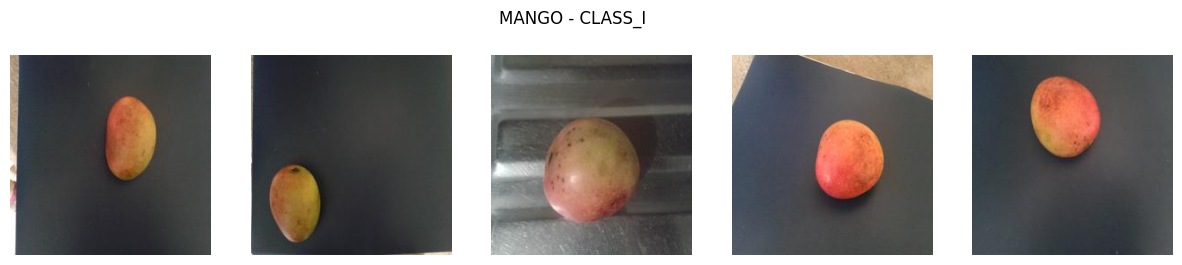

In [56]:
show_samples("mango", "class_I")

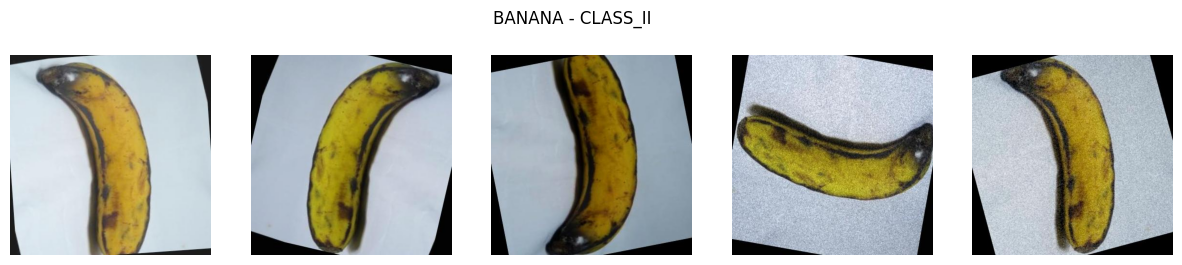

In [58]:
show_samples("banana", "class_II")

In [43]:
sizes = []

for fruit in os.listdir(DATASET_PATH):
    fruit_path = os.path.join(DATASET_PATH, fruit)
    if os.path.isdir(fruit_path):
        for quality in os.listdir(fruit_path):
            quality_path = os.path.join(fruit_path, quality)
            for img_name in os.listdir(quality_path):
                img_path = os.path.join(quality_path, img_name)
                img = cv2.imread(img_path)
                if img is not None:
                    sizes.append(img.shape[:2])

sizes_df = pd.DataFrame(sizes, columns=["Height", "Width"])
sizes_df.describe()

,Height,Width
count,14886.000000,14886.000000
mean,355.887680,416.730552
std,96.426685,153.239052
min,116.000000,109.000000
25%,300.000000,310.000000
50%,382.000000,416.000000
75%,416.000000,494.000000
max,2400.000000,3200.000000


In [59]:
broken_count = 0

for root, _, files in os.walk(DATASET_PATH):
    for file in files:
        img_path = os.path.join(root, file)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            broken_count += 1

print("Broken images found:", broken_count)

Broken images found: 0


In [61]:
from collections import defaultdict

class_count = defaultdict(int)

for root, _, files in os.walk(DATASET_PATH):
    if files:
        fruit = root.split(os.sep)[-2]
        quality = root.split(os.sep)[-1]
        class_count[(fruit, quality)] = len(files)

for (fruit, quality), count in class_count.items():
    print(f"{fruit:10s} | {quality:10s} | {count}")

apple      | class_I    | 2160
apple      | rotten     | 2992
banana     | class_I    | 2047
banana     | class_II   | 2293
banana     | rotten     | 2805
mango      | class_I    | 897
mango      | class_II   | 291
mango      | rotten     | 1401
